In [2]:
import numpy as np
import py4DSTEM as p4
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

In [3]:
import os
import sys
# List h5 files in path directory containing "master" in filename
path = "/Volumes/Extreme SSD/Data/250801/"
h5_files = [f for f in os.listdir(path) if f.endswith('.h5') and 'master' in f]
print("\nH5 files containing 'master':")
for f in h5_files:
    print(f)


H5 files containing 'master':
07292025_roi12_Au__622urad_35us_CL_91_00_master.h5
07292025_roi12_Au__622urad_35us_CL_91_01_master.h5
250801_Au_2mrad_115mm_00_master.h5
250801_Au_2mrad_145mm_00_master.h5
250801_Au_2mrad_185mm_00_master.h5
250801_Au_2mrad_185mm_01_master.h5
250801_Au_2mrad_58mm_00_master.h5
250801_Au_2mrad_73mm_00_master.h5
250801_Au_2mrad_91mm_00_master.h5
250801_Au_2mrad_91mm_01_master.h5
250801_Au_2mrad_91mm_02_master.h5
250801_JJ_2mrad_115mm_00_master.h5
250801_JJ_2mrad_115mm_01_master.h5
250801_JJ_2mrad_115mm_02_master.h5
250801_JJ_2mrad_115mm_03_master.h5
250801_JJ_2mrad_115mm_04_master.h5
250801_JJ_2mrad_145mm_00_master.h5
250801_Au_2mrad_145mm_00_master_masked.h5
._250801_Au_2mrad_145mm_00_master_masked.h5
250801_Au_2mrad_145mm_00_master_probe.h5
._250801_Au_2mrad_145mm_00_master_probe.h5
250801_Au_2mrad_115mm_00_master_masked.h5
._250801_Au_2mrad_115mm_00_master_masked.h5
250801_Au_2mrad_115mm_00_master_probe.h5
._250801_Au_2mrad_115mm_00_master_probe.h5
250801_

In [4]:
# set the path to the local copy of the dataset file
name = "250801_JJ_2mrad_145mm_00_master"
filepath_data = path + name + ".h5"

# load the data
datacube = p4.import_file(filepath_data)

# print results
print(datacube)

Dataset is uint32 but will be converted to uint16
DataCube( A 4-dimensional array of shape (512, 512, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)


In [6]:
cal_name = "250801_Au_2mrad_145mm_00_master_masked.h5"
cal_probe_name = "250801_Au_2mrad_145mm_00_master_probe.h5"

cal_datacube = p4.read(
    filepath = f'{path}{cal_name}',
)

cal_probe = p4.read(
    filepath = f'{path}{cal_probe_name}',
)

Reading PointListArray: 100%|██████████| 16384/16384 [00:01<00:00, 9435.85PointList/s] 


In [7]:
datacube.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    1
             R_pixel_size:    1
             Q_pixel_units:   pixels
             R_pixel_units:   pixels
             QR_flip:         False
)

In [11]:
q_pixel_size = cal_datacube.calibration.Q_pixel_size
q_pixel_unit = cal_datacube.calibration.Q_pixel_units


In [12]:
datacube.calibration.set_Q_pixel_size(q_pixel_size)
datacube.calibration.set_Q_pixel_units(q_pixel_unit)

In [13]:
datacube.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    0.02
             R_pixel_size:    1
             Q_pixel_units:   A^-1
             R_pixel_units:   pixels
             QR_flip:         False
)

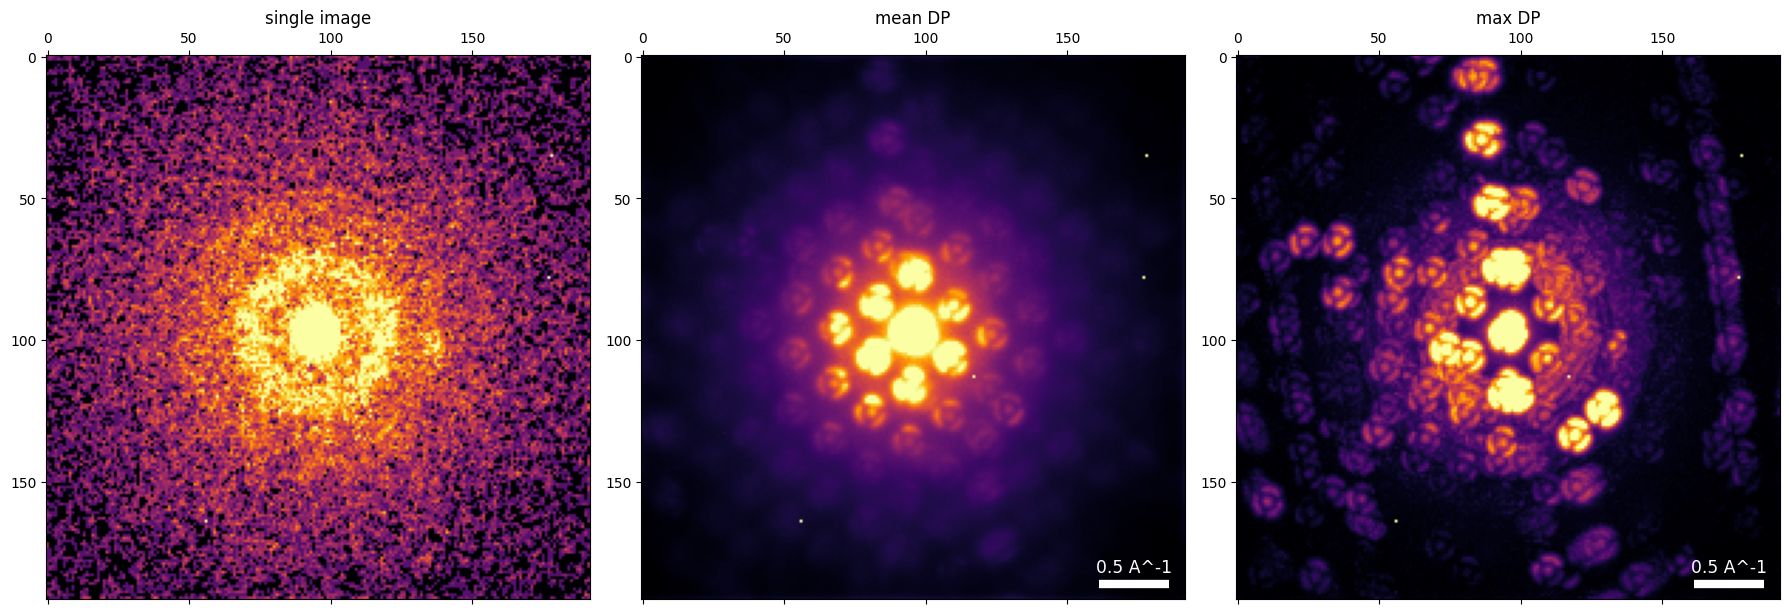

In [17]:
p4.show(
    [datacube.data[40,20],datacube.get_dp_mean(),datacube.get_dp_max()],
    cmap = 'inferno',
    title = ['single image','mean DP','max DP'],
    power = 0.5,
)

In [ ]:
dataset_masked = []
for data in [datacube,]:
    mask_hotpixel = data.tree('dp_mean').data>65530
    masked = data.median_filter_masked_pixels(mask = mask_hotpixel, kernel_width = 5)
    masked.get_dp_max();
    masked.get_dp_mean();
    # Plot the hot pixel mask
    p4.show(
        mask_hotpixel,
        cmap='gray',
        figsize=(4,4),
        ticks=False,
        title='Hot Pixel Mask (white = masked)',
    )
    plt.show()
    dataset_masked.append(masked)
    print('Maximum value', np.max(masked.tree('dp_max').data))
datacube_masked = dataset_masked[0]